<h3  style = "color: skyblue" >Importing Libraries<h3>

In [22]:
import time
import torch
import seaborn as sns
from torchvision import models
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import optim
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import transforms, datasets
from torch.utils.data import random_split, DataLoader

<h3 style = "color: skyblue" >GPU Acceleration</h3>

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


<h3  style = "color: skyblue" >Data Ingestion and Transformation<h3>

In [6]:
dataset_path = "../data"

transform = transforms.Compose([

    #Data Augmentation
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    #Normal Transformation
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

])

dataset = datasets.ImageFolder(root= dataset_path, transform= transform)

<h3 style = "color:skyblue" >Data Overview</h3>

In [7]:
print(f"The Size of Dataset: {len(dataset)}")
print(f"The number of classes: {len(dataset.classes)}")
print("==" * 15)
print("\nThe Classes:")
class_name = dataset.classes
print(class_name)

The Size of Dataset: 200000
The number of classes: 2

The Classes:
['ai', 'real']


In [8]:
dataset.class_to_idx

{'ai': 0, 'real': 1}

<h3 style = "color:skyblue" >Data Splitting</h3>

In [9]:
train_size = int(len(dataset) * 0.75)
val_size  = int(len(dataset) - train_size)

train_size, val_size

(150000, 50000)

In [10]:
train_dataset, val_dataset = random_split(dataset= dataset, lengths=[train_size, val_size])

print("After Random Splitting:\n")
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")

After Random Splitting:

Train size: 150000
Validation size: 50000


<h3 style = "color:skyblue" >Batching</h3>

In [11]:
batch_size = 32

train_loader = DataLoader(dataset= train_dataset, batch_size= batch_size, shuffle= True)

val_loader = DataLoader(dataset= val_dataset, batch_size= batch_size, shuffle= True)

In [12]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [13]:
images[0].shape

torch.Size([3, 224, 224])

In [14]:
labels[0]

tensor(0)

<h3 style = "color:skyblue" >Visualizing  One Image</h3>

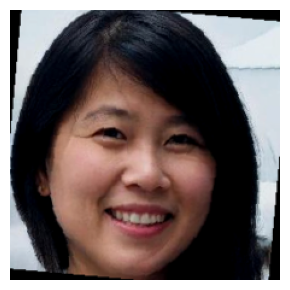

In [15]:
# Take one image from batch (C, H, W):
img = images[0]

# Convert to (H, W, C)
img = img.permute(1, 2, 0)

# Unnormalize
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

img = img * std + mean

# Clip to valid range
img = img.clamp(0, 1)

# Plot
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()


Transfer Learning implementation with ResNet

In [16]:
class DeepFakeClassifierResNet(nn.Module):

    def __init__(self, num_classes, dropout_rate):
        super().__init__()
        
        self.model = models.resnet50(weights= "DEFAULT")

        for params in self.model.parameters():
            params.requires_grad = False

        for params in self.model.layer4.parameters():
            params.requires_grad = True

        self.model.fc = nn.Sequential(

            nn.Dropout(p= dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):

        x = self.model(x)

        return x

        

In [17]:
model = DeepFakeClassifierResNet(num_classes=1, dropout_rate= 0.3).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda x:x.requires_grad, model.parameters()), lr = 0.001)

In [ ]:
def train_model(model, criterion, optimizer, epochs = 5):

    start = time.time()

    for epoch in range(epochs):
        #Training
        model.train()
        running_loss = 0.0

        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            #Zero the previous additive grads
            optimizer.zero_grad()

            #Forward Prop
            outputs = model(images)
            loss = criterion(outputs.squeeze(1).float(), labels.float())

            #Backward Prop and update parameters
            loss.backward()
            optimizer.step()

            if (batch_num + 1) % 1000 == 0:
                print(f"Batch: {batch_num +1} - Epoch: {epoch + 1} - Loss: {loss.item(): 0.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch[{epoch + 1}/ {epochs}] - Avg Loss: {epoch_loss:0.4f}")


        #Validation
        model.eval()
        correct = 0
        total = 0
        all_labels, all_predictions = [], []

        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                probs = torch.sigmoid(outputs)
                predicted = (probs > 0.5).float().squeeze(1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f"*** Validation Accuracy: {100 * correct / total : 0.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds") 


    return all_labels, all_predictions

In [19]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs= 5)

Batch: 1000 - Epoch: 1 - Loss:  0.14
Batch: 2000 - Epoch: 1 - Loss:  0.28
Batch: 3000 - Epoch: 1 - Loss:  0.18
Batch: 4000 - Epoch: 1 - Loss:  0.25
Epoch[1/5] - Avg Loss: 0.2495
*** Validation Accuracy:  92.65% ***
Batch: 1000 - Epoch: 2 - Loss:  0.07
Batch: 2000 - Epoch: 2 - Loss:  0.12
Batch: 3000 - Epoch: 2 - Loss:  0.22
Batch: 4000 - Epoch: 2 - Loss:  0.12
Epoch[2/5] - Avg Loss: 0.1568
*** Validation Accuracy:  93.65% ***
Batch: 1000 - Epoch: 3 - Loss:  0.16
Batch: 2000 - Epoch: 3 - Loss:  0.11
Batch: 3000 - Epoch: 3 - Loss:  0.05
Batch: 4000 - Epoch: 3 - Loss:  0.12
Epoch[3/5] - Avg Loss: 0.1320
*** Validation Accuracy:  94.05% ***
Batch: 1000 - Epoch: 4 - Loss:  0.11
Batch: 2000 - Epoch: 4 - Loss:  0.10
Batch: 3000 - Epoch: 4 - Loss:  0.06
Batch: 4000 - Epoch: 4 - Loss:  0.26
Epoch[4/5] - Avg Loss: 0.1165
*** Validation Accuracy:  94.56% ***
Batch: 1000 - Epoch: 5 - Loss:  0.04
Batch: 2000 - Epoch: 5 - Loss:  0.19
Batch: 3000 - Epoch: 5 - Loss:  0.19
Batch: 4000 - Epoch: 5 - Loss

<h3 style = "color:skyblue" >Model Evaluation using Confusion Matrix and Classification Report</h3>

In [20]:
report = classification_report(all_labels, all_predictions)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     25143
           1       0.95      0.96      0.95     24857

    accuracy                           0.95     50000
   macro avg       0.95      0.95      0.95     50000
weighted avg       0.95      0.95      0.95     50000



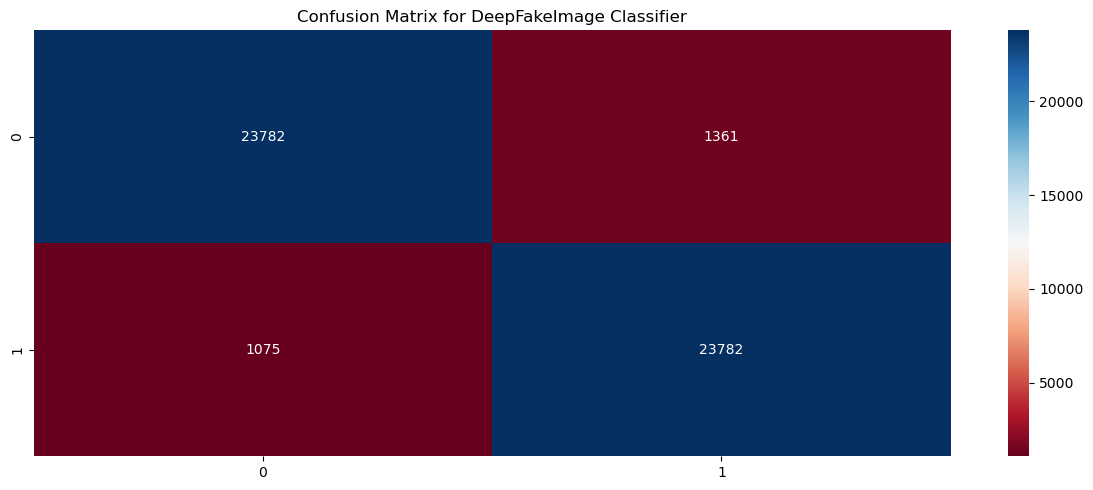

In [28]:
plt.figure(figsize=(12,5))
cm= confusion_matrix(all_labels, all_predictions)
sns.heatmap(data = cm, cmap= "RdBu", annot= True, fmt="d")
plt.title("Confusion Matrix for DeepFakeImage Classifier")
plt.tight_layout()
plt.show();

<h3 style = "color:skyblue" >Persisting Model</h3>

In [30]:
torch.save(model.state_dict(), "../artifacts/model.pth")